In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from mtpy import MTData
from mtpy.modeling import StructuredGrid3D


In [2]:
save_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\cvcm_01")
save_path.mkdir(exist_ok=True, parents=True)

In [3]:
topo_fn = Path(r"c:\Users\jpeacock\OneDrive - DOI\western_us.tiff")

# Build Data File

In [64]:
extent = {"lon_min": -118.303, "lon_max": -117.216, "lat_min": 37.612, "lat_max": 38.425}

In [70]:
edi_path = Path(r"C:\Users\jpeacock\OneDrive - DOI\EDI_FILES\latest_files")

In [71]:
edi_df = pd.read_csv(edi_path / "edi_file_summary_2026_03_09.csv")

In [72]:
cv_df = edi_df.loc[
    (edi_df.latitude >= extent["lat_min"])
    & (edi_df.latitude <= extent["lat_max"])
    & (edi_df.longitude >= extent["lon_min"])
    & (edi_df.longitude <= extent["lon_max"])
]

In [73]:
edi_list = [edi_path / filename for filename in cv_df.filename.tolist()]
print(f"Number of EDI files in Clayton Valley: {len(edi_list)}")

Number of EDI files in Clayton Valley: 73


## Make Data File

In [74]:
md = MTData()
md.utm_epsg = 32611
md.add_station(edi_list, compute_relative_location=False)
md.compute_relative_locations()

26:03:09T15:11:08 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts_per_kilometer_per_nanotesla' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:03:09T15:11:08 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:03:09T15:11:09 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:03:09T15:11:09 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts_per_kilometer_per_nanotesla' not found in accepted units, setting to 'unknown'. If this is a

In [75]:
new_periods = np.logspace(np.log10(1/700), np.log10(8000), 23)

In [76]:
md_interp = md.interpolate(new_periods, inplace=False)

26:03:09T15:11:55 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm201: Using mean rotation angle of -12.60 degrees.
26:03:09T15:11:56 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm202: Using mean rotation angle of -12.60 degrees.
26:03:09T15:11:56 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm203: Using mean rotation angle of -12.60 degrees.
26:03:09T15:11:56 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm204: Using mean rotation angle of -12.60 degrees.
26:03:09T15:11:57 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm205: Using mean rotation angle of -12.60 degrees.
26:03:09T15:11:57 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm206: Using mean rotation angle of -12.60 degrees.
26:03:09T15:11:57 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm207: Using mean rotation angle of -12.60 degrees.
26:03:09T15:11:57 | WARNING | line:882 |mtpy.core.mt | interpolate | Station cm208: Using mean ro

In [77]:
md_interp.z_model_error.error_value =0.03
md_interp.z_model_error.error_type = "eigen"
md_interp.z_model_error.floor = True
md_interp.t_model_error.error_value = 0.02
md_interp.t_model_error.error_type = "absolute"
md_interp.t_model_error.floor = True

md.compute_model_errors()

In [78]:
modem_data = md_interp.to_modem(save_path / "cvcm_modem_data_z03_t02.dat")

26:03:09T15:12:51 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xx 1452 times. Setting error as z_xx x 0.03.
26:03:09T15:12:51 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xy 1452 times. Setting error as z_xy x 0.03.
26:03:09T15:12:51 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yx 1452 times. Setting error as z_yx x 0.03.
26:03:09T15:12:51 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yy 1452 times. Setting error as z_yy x 0.03.
26:03:09T15:12:51 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in t_zx 1452 times. Setting error as t_zx x 0.02.
26:03:09T15:12:51 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 

In [4]:
modem_md = MTData()
modem_md.from_modem(save_path / "cvcm_modem_data_z03_t02_tec_02.dat")
modem_md.compute_relative_locations()

# Make Model 

Structured3DMesh Model Object:
--------------------
	Number of stations = 69
	Mesh Parameter: 
		cell_size_east:    1250
		cell_size_north:   1250
		pad_east:          10
		pad_north:         10
		pad_num:           5
		z1_layer:          30
		z_target_depth:    80000
		n_layers:          65
		n_air_layers:      25
		res_initial_value: 80
	Dimensions: 
		e-w: 105
		n-s: 103
		z:   66 (without 7 air layers)
	Extensions: 
		e-w:  303000.0 (m)
		n-s:  300500.0 (m)
		0-z:  384995.9 (m)
--------------------
26:03:09T16:40:31 | WARNING | line:49 |mtpy.modeling.plots.plot_mesh | _plot_topography | Cannot find topography information, skipping
26:03:09T16:40:31 | WARNING | line:89 |mtpy.modeling.plots.plot_mesh | _plot_topography_ax2 | Cannot find topography information, skipping


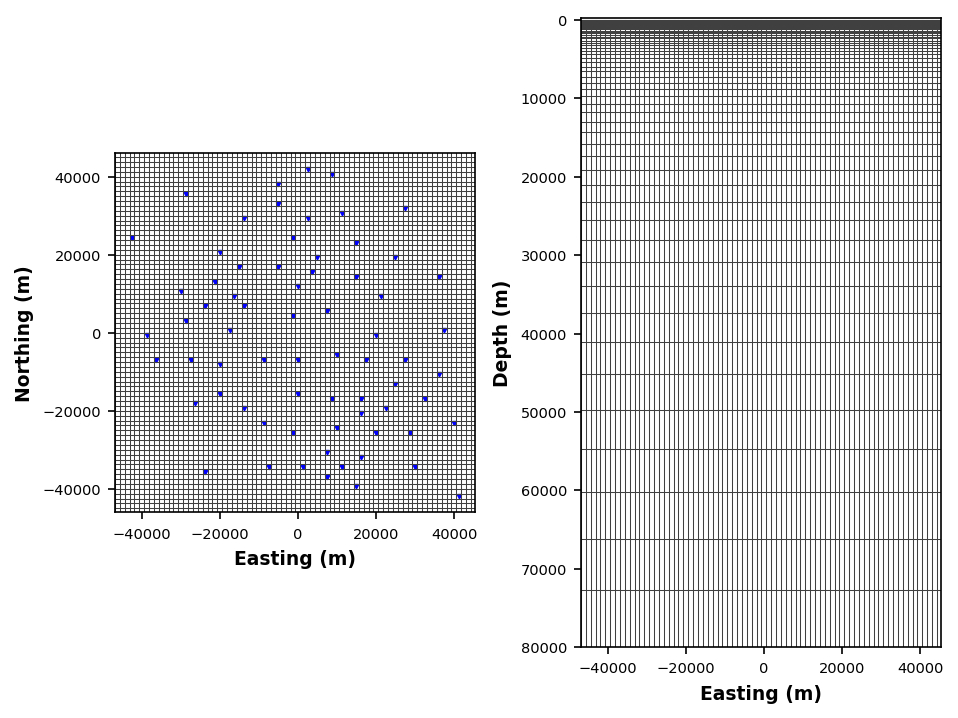

Plotting PlotMesh

In [29]:
s = StructuredGrid3D(
    station_locations=modem_md.station_locations,
    center_point=modem_md.center_point,
)

s.cell_size_east = 1250
s.cell_size_north = 1250
s.pad_east = 10
s.pad_north = 10
s.pad_num = 5
s.ew_ext = 300000
s.ns_ext = 300000
s.z_mesh_method = "default"
s.z_bottom = 600000
s.z_target_depth = 80000
s.pad_z = 6
s.n_air_layers = 25
s.n_layers = 65
s.z1_layer = 30
s.pad_stretch_v = 1.6
s.z_layer_rounding = 1
s.res_initial_value = 80

s.make_mesh()
s.plot_mesh()


In [30]:
s.add_topography_to_model(
    topography_file=topo_fn,
    max_elev=2400,
    airlayer_type="constant",
    shift_east=0,
    shift_north=0,
)
print(s)

Read geotiff surface file
1296.9805908203125 2400
26:03:09T16:40:32 | INFO | line:1629 |mtpy.modeling.structured_mesh_3d | add_topography_to_model | Using constant air layer thickness of 30 m, which results in 37.0 air layers to cover the topography
Structured3DMesh Model Object:
--------------------
	Number of stations = 69
	Mesh Parameter: 
		cell_size_east:    1250
		cell_size_north:   1250
		pad_east:          10
		pad_north:         10
		pad_num:           5
		z1_layer:          30
		z_target_depth:    80000
		n_layers:          65
		n_air_layers:      37
		res_initial_value: 80
	Dimensions: 
		e-w: 105
		n-s: 103
		z:   103 (without 7 air layers)
	Extensions: 
		e-w:  303000.0 (m)
		n-s:  300500.0 (m)
		0-z:  386105.9 (m)
--------------------


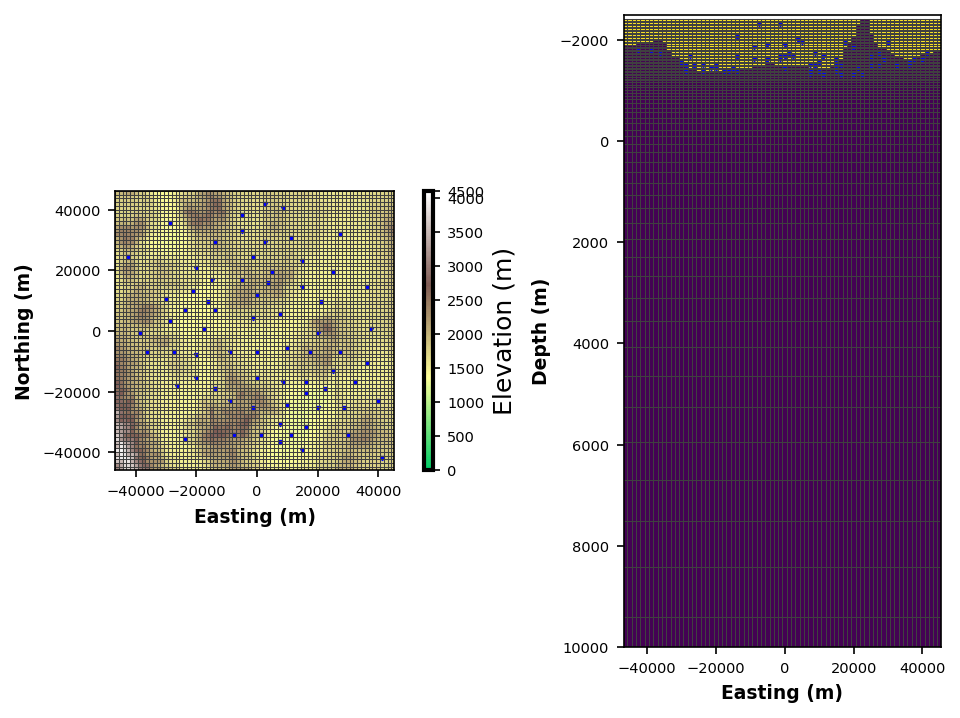

26:03:09T16:40:36 | INFO | line:830 |mtpy.modeling.structured_mesh_3d | to_modem | Wrote file to: c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\cvcm_01\cvcm_sm70.dat


In [ ]:
modem_md.center_stations(s)
modem_md.project_stations_on_topography(s)

s.station_locations = modem_md.station_locations
s.plot_mesh(z_limits=(10000, -2500), show_stations=True)
s.to_modem(save_path / "cvcm_sm70.rho")

In [34]:
modem_md = MTData()
modem_md.from_modem(save_path / "cvcm_modem_data_z03_t02_tec_02.dat")
modem_md.compute_relative_locations()

In [36]:
s = StructuredGrid3D(modem_md.station_locations, center_point=modem_md.center_point)
s.from_modem(save_path / "cvcm_sm70.rho")


In [37]:
modem_md.center_stations(s)
modem_md.project_stations_on_topography(s)

In [38]:
modem_md.to_modem(save_path / "cvcm_modem_data_z03_t02_tec.dat", inv_mode="1")
modem_md.z_model_error.error_value = 10
modem_md.z_model_error.error_type = "eigen"
modem_md.t_model_error.error_value = 0.03
modem_md.compute_model_errors()

survey = "cvcm"
modem_md.to_modem(save_path / (f"{survey}_modem_data_z10_tec.dat"), inv_mode="2")
modem_md.to_modem(save_path / (f"{survey}_modem_data_t03_tec.dat"), inv_mode="5")

26:03:09T16:43:22 | WARNING | line:539 |mtpy.modeling.modem.data | _check_for_too_small_errors | Found errors with values less than 0.02 in t_zx 542 times. Setting error as t_zx x 0.02.
26:03:09T16:43:22 | WARNING | line:539 |mtpy.modeling.modem.data | _check_for_too_small_errors | Found errors with values less than 0.02 in t_zy 530 times. Setting error as t_zy x 0.02.
26:03:09T16:43:23 | INFO | line:652 |mtpy.modeling.modem.data | write_data_file | Wrote ModEM data file to c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\cvcm_01\cvcm_modem_data_z03_t02_tec.dat
26:03:09T16:43:32 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xx 11 times. Setting error as z_xx x 0.1.
26:03:09T16:43:32 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xy 11 times. Setting error as z_xy x 0.1.
26:03:09T16:43:32 | WARNING | line:515 |mtpy.modeling.modem.data | _chec

ModEM Data Object:
	Number of impedance stations: 69
	Number of tipper stations: 69
	Number of phase tensor stations: 69
	Number of periods:  23
	Period range (s):  
		Min: 0.0014286
		Max: 8000
	Rotation angle:     0.0
	Data center:        
		Latitude:   38.0106 deg 	Northing: 4207263.9618 m
		Longitude: -117.7548 deg 	Easting: 433743.8081 m
		Datum epsg: 4326			UTM epsg:   32611
		Elevation:  -2407.0 m
	Impedance data:     True
	Tipper data:        True
	Inversion Mode:   Full_Vertical_Components

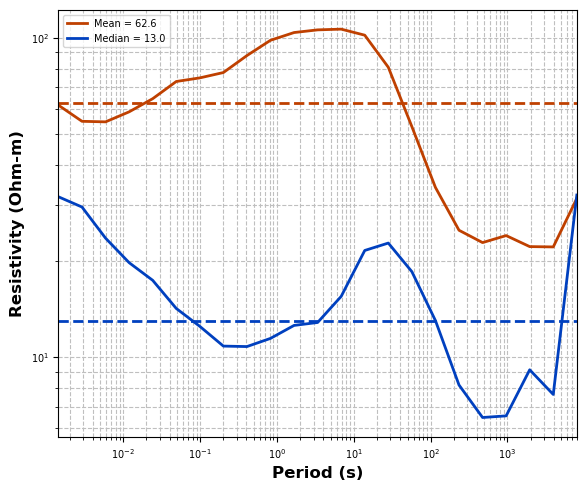

In [40]:
modem_md.estimate_starting_rho()

In [41]:
from mtpy.modeling.modem import Covariance

cov = Covariance(grid_dimensions=s.res_model.shape)
cov.smoothing_east = 0.7
cov.smoothing_north = 0.7
cov.smoothing_vertical = 0.4
cov.write_covariance_file(save_path / "cvcm_covariance.cov")


26:03:09T16:46:11 | INFO | line:232 |mtpy.modeling.modem.convariance | write_covariance_file | Wrote covariance file to c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\cvcm_01\cvcm_covariance.cov


In [23]:
500 * np.sqrt(1./700*30)

np.float64(103.50983390135313)